In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import random

In [2]:
forged_pics = []
forged_dir = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged'
for pic in os.listdir(forged_dir):
    forged_pics.append(os.path.join(forged_dir, pic))

In [3]:
forged_masks = []
masks_dir = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks'
for pic in os.listdir(masks_dir):
    forged_masks.append(os.path.join(masks_dir, pic))

In [4]:
print(len(forged_pics))
print(len(forged_masks))

2751
2751


In [5]:
forged_pics.sort()
forged_masks.sort()

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/49770.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/49770.npy
Mask shape before processing: (1, 1024, 1280)


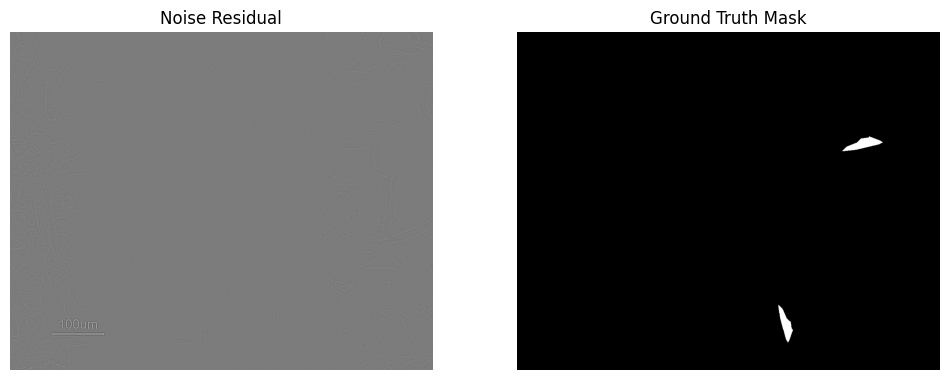

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/20882.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/20882.npy
Mask shape before processing: (1, 501, 98)


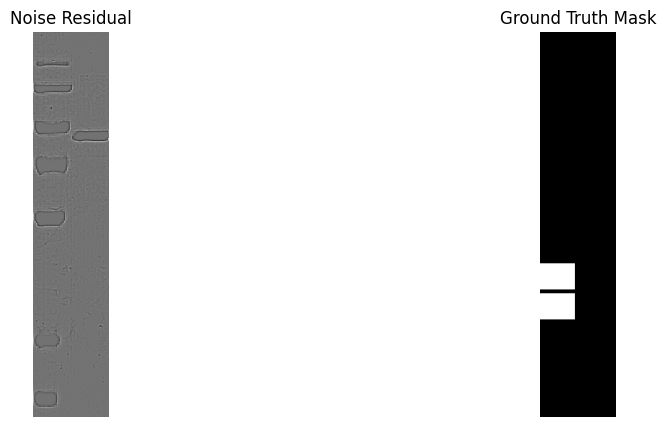

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/1813.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/1813.npy
Mask shape before processing: (2, 816, 360)


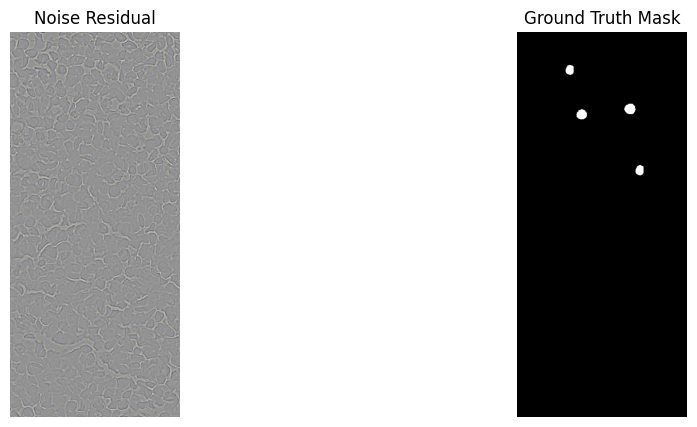

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/56311.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/56311.npy
Mask shape before processing: (1, 131, 541)


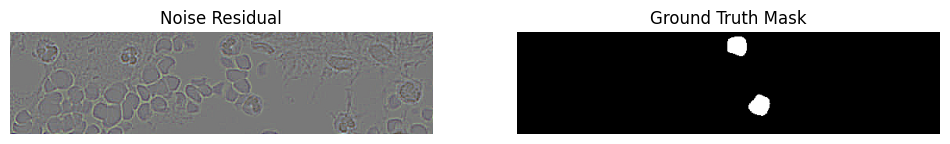

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/12063.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/12063.npy
Mask shape before processing: (2, 520, 696)


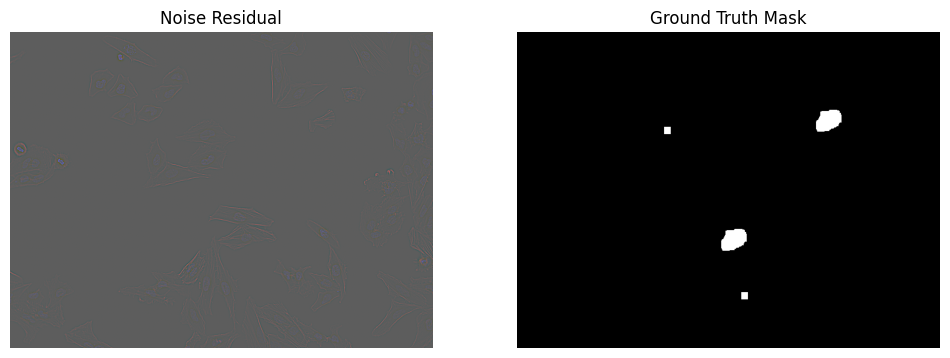

In [6]:
for i in range(5):
    # Pick a random image
    x = random.randint(0, len(forged_pics)-1)
    pic = forged_pics[x]
    mask_path = forged_masks[x]

    print(f"Image: {pic}")
    print(f"Mask: {mask_path}")

    # --- Load image ---
    img = cv2.imread(pic)
    img = img.astype(np.float32) / 255.0

    # --- Compute noise residual ---
    blur = cv2.GaussianBlur(img, (5,5), 0)
    noise = img - blur
    noise_rgb = cv2.cvtColor(noise, cv2.COLOR_BGR2RGB)
    noise_vis = (noise_rgb - noise_rgb.min()) / (noise_rgb.max() - noise_rgb.min() + 1e-8)

    # --- Load mask robustly ---
    if not os.path.exists(mask_path):
        print(f"Mask not found! Using zeros for {pic}")
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    else:
        mask = np.load(mask_path)

    print(f"Mask shape before processing: {mask.shape}")

    # --- Standardize mask to 2D ---
    if mask.ndim == 3:
        if mask.shape[0] > 1:        # (C,H,W)
            mask = mask.max(axis=0)
        elif mask.shape[0] == 1:     # (1,H,W)
            mask = mask[0]
        elif mask.shape[2] > 1:      # (H,W,C)
            mask = mask.max(axis=2)
        elif mask.shape[2] == 1:     # (H,W,1)
            mask = mask[:,:,0]
    # Now mask is 2D (H,W)

    # --- Ensure binary mask ---
    mask = mask.astype(np.float32)
    mask = (mask > 0).astype(np.uint8)  # any positive value counts as forged

    # --- Normalize for visualization ---
    mask_vis = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    # --- Visualize ---
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(noise_vis)
    plt.title("Noise Residual")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask_vis, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.show()

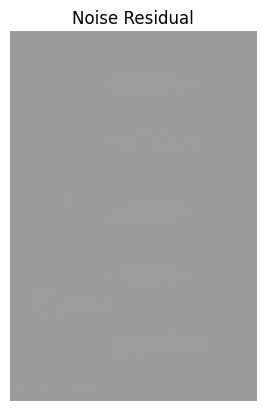

In [7]:
img = cv2.imread("/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/10138.png")
img = img.astype(np.float32) / 255.0

# Blur image
blur = cv2.GaussianBlur(img, (5,5), 0)

# Noise residual
noise = img - blur
noise_rgb = cv2.cvtColor(noise, cv2.COLOR_BGR2RGB)

# Normalize for visualization
noise_vis = (noise_rgb - noise_rgb.min()) / (noise_rgb.max() - noise_rgb.min())

plt.figure()
plt.imshow(noise_vis)
plt.title("Noise Residual")
plt.axis("off")
plt.show()

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/24012.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/24012.npy
Mask shape before processing: (1, 512, 697)


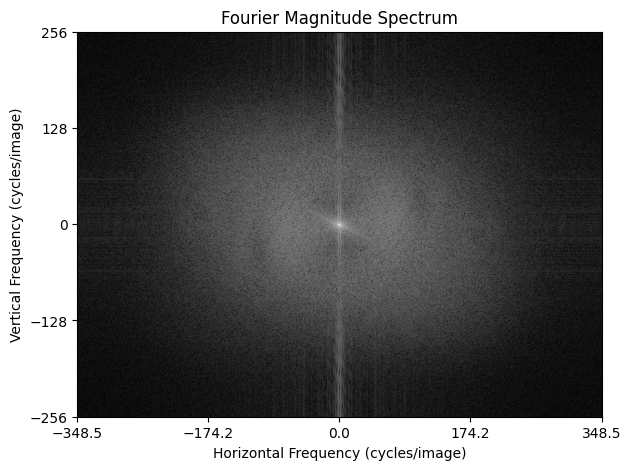

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/65465.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/65465.npy
Mask shape before processing: (2, 256, 256)


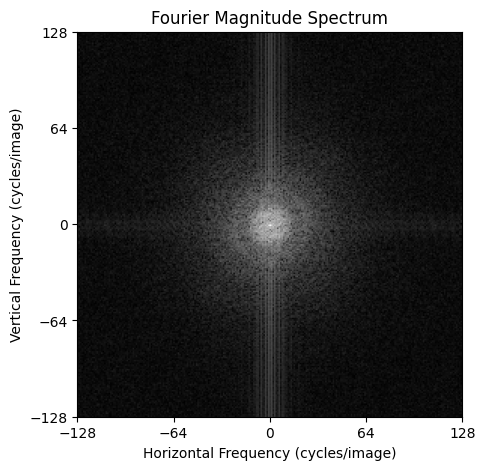

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/57883.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/57883.npy
Mask shape before processing: (2, 1200, 1600)


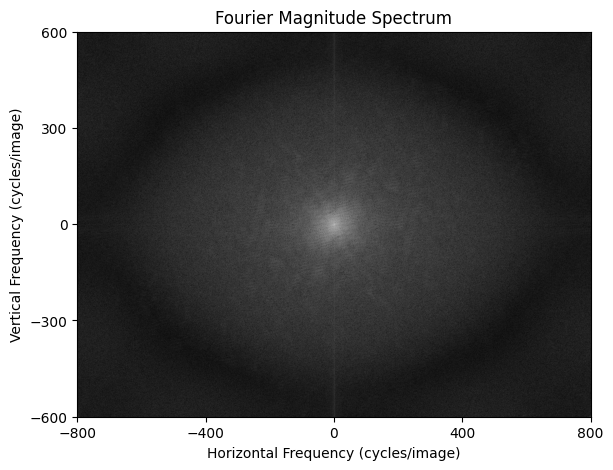

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/36245.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/36245.npy
Mask shape before processing: (1, 666, 1000)


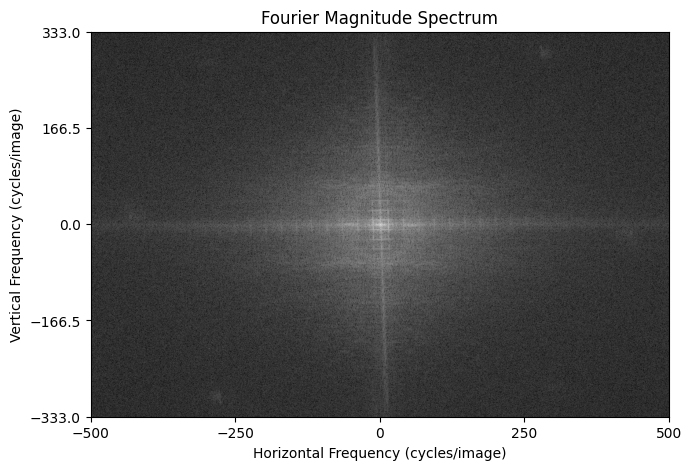

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/51924.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/51924.npy
Mask shape before processing: (1, 512, 589)


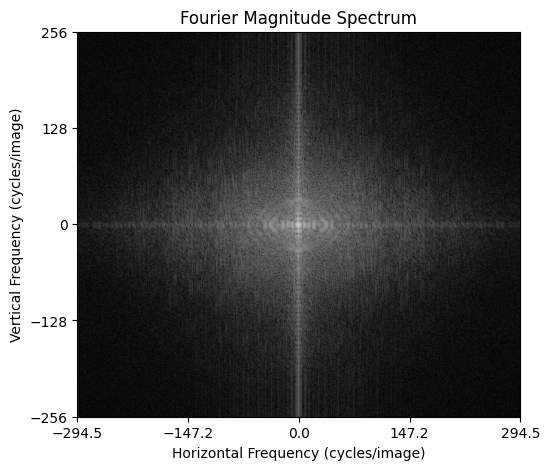

In [8]:
for i in range(5):
    # Pick a random image
    x = random.randint(0, len(forged_pics)-1)
    pic = forged_pics[x]
    mask_path = forged_masks[x]
    print(f"Image: {pic}")
    print(f"Mask: {mask_path}")
    # --- Load image ---
    img = cv2.imread(pic)
    img = img.astype(np.float32) / 255.0
    # --- Compute Fourier magnitude spectrum ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log(np.abs(fft_shift) + 1)
    # --- Normalize magnitude for visualization ---
    magnitude_vis = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min() + 1e-8)
    # --- Load mask robustly ---
    if not os.path.exists(mask_path):
        print(f"Mask not found! Using zeros for {pic}")
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    else:
        mask = np.load(mask_path)
    print(f"Mask shape before processing: {mask.shape}")
    # --- Standardize mask to 2D ---
    if mask.ndim == 3:
        if mask.shape[0] > 1: # (C,H,W)
            mask = mask.max(axis=0)
        elif mask.shape[0] == 1: # (1,H,W)
            mask = mask[0]
        elif mask.shape[2] > 1: # (H,W,C)
            mask = mask.max(axis=2)
        elif mask.shape[2] == 1: # (H,W,1)
            mask = mask[:,:,0]
    # Now mask is 2D (H,W)
    # --- Ensure binary mask ---
    mask = mask.astype(np.float32)
    mask = (mask > 0).astype(np.uint8) # any positive value counts as forged
    # --- Normalize mask for visualization ---
    mask_vis = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    # --- Visualize with centered frequency axes ---
    height, width = magnitude_vis.shape
    # Assuming square image for simplicity; adjust if not
    plt.figure(figsize=(12,5))
    plt.imshow(magnitude_vis, cmap='gray', extent=[-width/2, width/2, -height/2, height/2])
    plt.title("Fourier Magnitude Spectrum")
    plt.xlabel("Horizontal Frequency (cycles/image)")
    plt.ylabel("Vertical Frequency (cycles/image)")
    # Set ticks to show negatives (e.g., 5 ticks)
    plt.xticks(np.linspace(-width/2, width/2, num=5))
    plt.yticks(np.linspace(-height/2, height/2, num=5))
    plt.show()

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/32428.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/32428.npy
Mask shape before processing: (3, 1024, 1024)


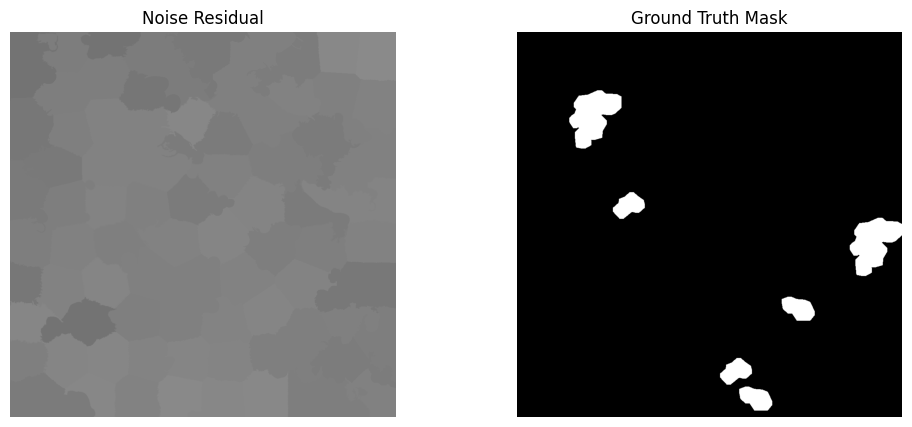

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/25638.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/25638.npy
Mask shape before processing: (2, 1024, 1024)


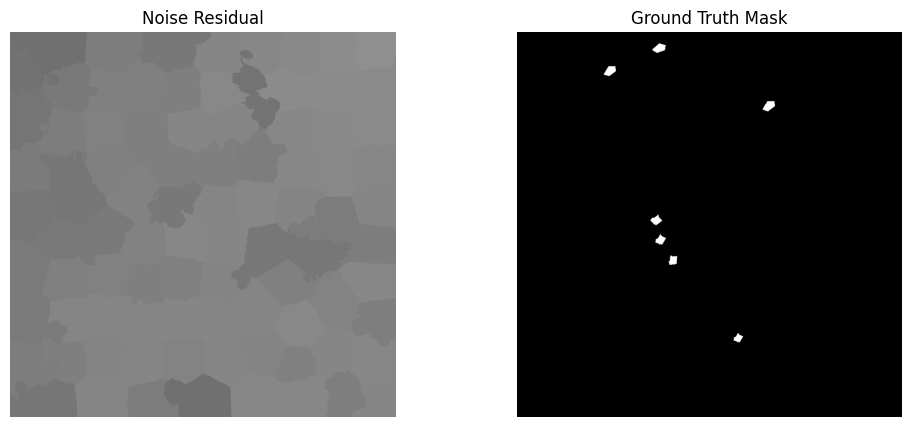

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/58723.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/58723.npy
Mask shape before processing: (2, 256, 256)


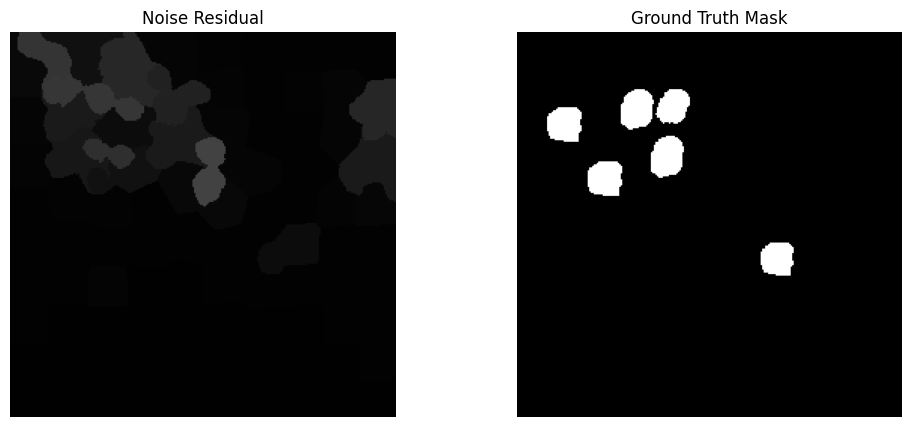

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/9967.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/9967.npy
Mask shape before processing: (1, 346, 620)


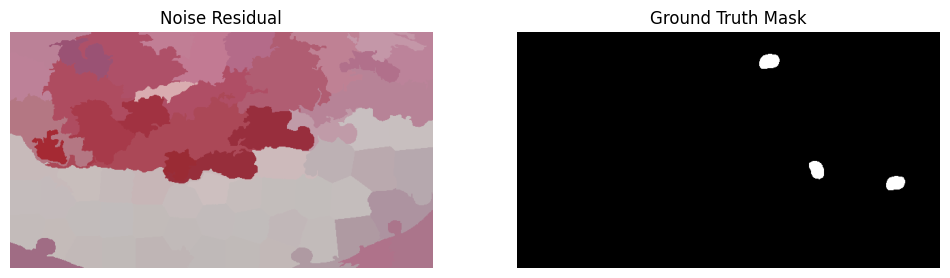

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/56442.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/56442.npy
Mask shape before processing: (2, 1024, 1280)


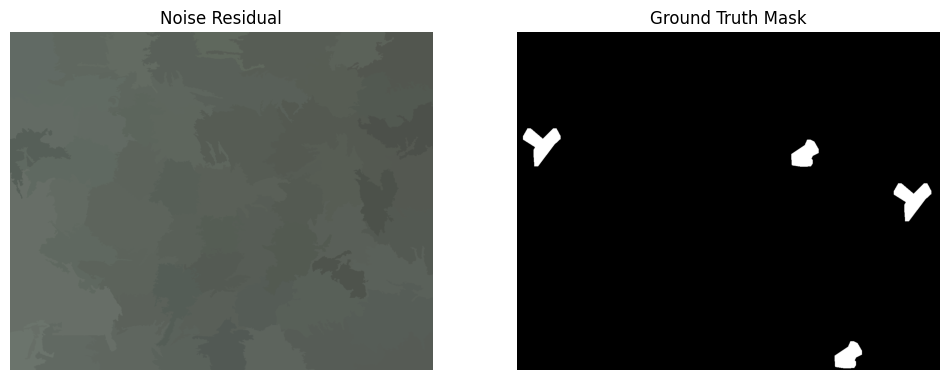

In [9]:
from skimage.segmentation import slic
from skimage.color import label2rgb

for i in range(5):
    # Pick a random image
    x = random.randint(0, len(forged_pics)-1)
    pic = forged_pics[x]
    mask_path = forged_masks[x]

    print(f"Image: {pic}")
    print(f"Mask: {mask_path}")

    # --- Load image ---
    img = cv2.imread(pic)
    img = img.astype(np.float32) / 255.0

    # --- Segment Image ---
    segments = slic(img)
    segmented_image = label2rgb(segments, img, kind='avg')

    # --- Load mask robustly ---
    if not os.path.exists(mask_path):
        print(f"Mask not found! Using zeros for {pic}")
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    else:
        mask = np.load(mask_path)

    print(f"Mask shape before processing: {mask.shape}")

    # --- Standardize mask to 2D ---
    if mask.ndim == 3:
        if mask.shape[0] > 1:        # (C,H,W)
            mask = mask.max(axis=0)
        elif mask.shape[0] == 1:     # (1,H,W)
            mask = mask[0]
        elif mask.shape[2] > 1:      # (H,W,C)
            mask = mask.max(axis=2)
        elif mask.shape[2] == 1:     # (H,W,1)
            mask = mask[:,:,0]
    # Now mask is 2D (H,W)

    # --- Ensure binary mask ---
    mask = mask.astype(np.float32)
    mask = (mask > 0).astype(np.uint8)  # any positive value counts as forged

    # --- Normalize for visualization ---
    mask_vis = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    # --- Visualize ---
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(segmented_image)
    plt.title("Noise Residual")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask_vis, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.show()

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/31540.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/31540.npy
Mask shape before processing: (1, 666, 1000)


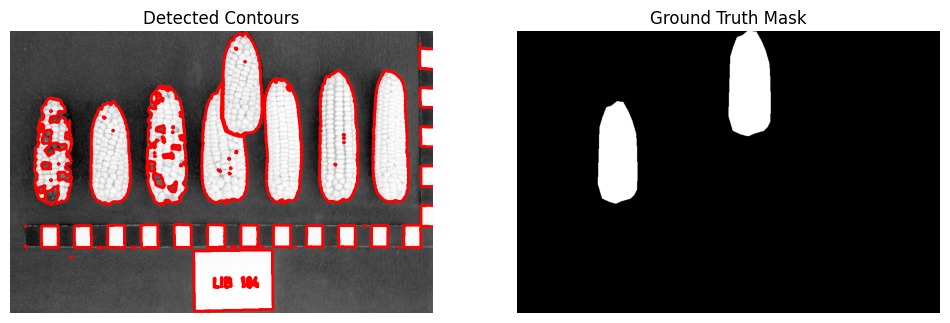

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/6566.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/6566.npy
Mask shape before processing: (2, 512, 512)


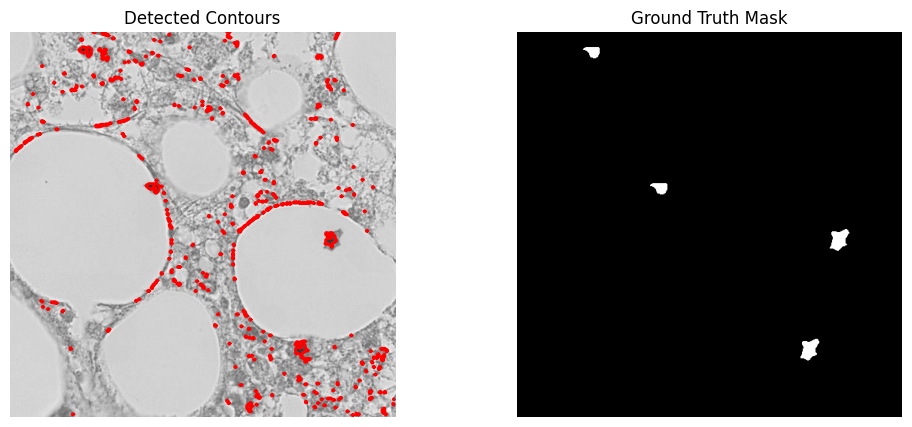

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/51718.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/51718.npy
Mask shape before processing: (1, 512, 512)


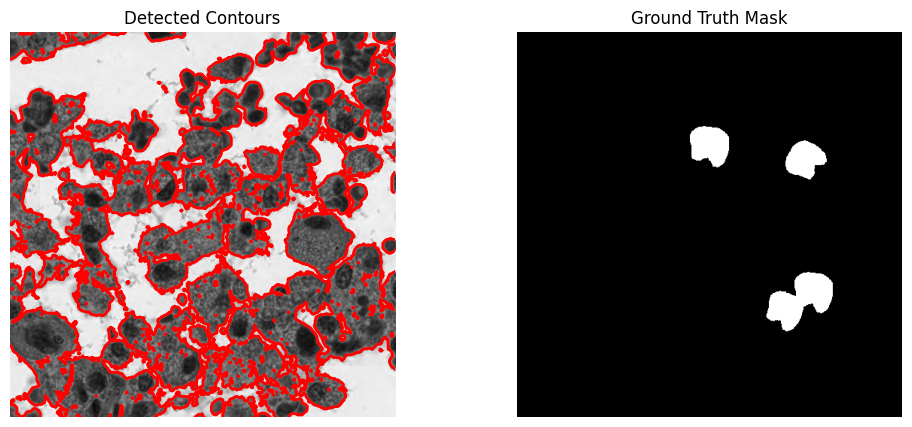

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/32053.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/32053.npy
Mask shape before processing: (2, 1200, 1600)


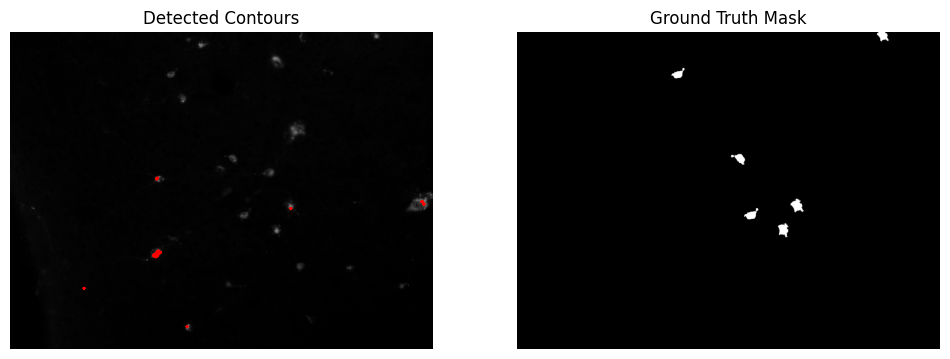

Image: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged/25340.png
Mask: /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks/25340.npy
Mask shape before processing: (1, 520, 696)


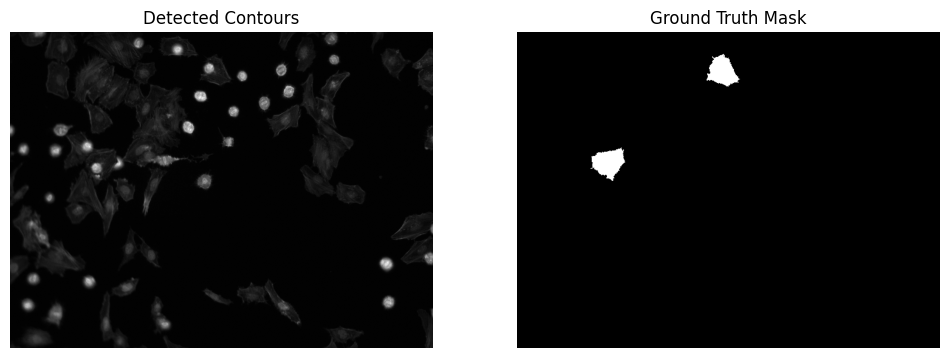

In [10]:
from skimage import measure

for i in range(5):

    x = random.randint(0, len(forged_pics)-1)
    pic = forged_pics[x]
    mask_path = forged_masks[x]

    print(f"Image: {pic}")
    print(f"Mask: {mask_path}")

    # --- Load image ---
    img = cv2.imread(pic)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.float32) / 255.0

    # --- Threshold for contour detection ---
    thresh = 0.6
    binary = (gray > thresh)

    # --- Find contours ---
    contours = measure.find_contours(binary, 0.8)

    # --- Load mask ---
    if not os.path.exists(mask_path):
        mask = np.zeros((gray.shape[0], gray.shape[1]), dtype=np.uint8)
    else:
        mask = np.load(mask_path)

    print(f"Mask shape before processing: {mask.shape}")

    # --- Convert mask to 2D ---
    if mask.ndim == 3:
        if mask.shape[0] > 1:
            mask = mask.max(axis=0)
        elif mask.shape[0] == 1:
            mask = mask[0]
        elif mask.shape[2] > 1:
            mask = mask.max(axis=2)
        elif mask.shape[2] == 1:
            mask = mask[:,:,0]

    mask = (mask > 0).astype(np.uint8)

    # --- Plot ---
    plt.figure(figsize=(12,5))

    # Image + contours
    plt.subplot(1,2,1)
    plt.imshow(gray, cmap='gray')

    for contour in contours:
        plt.plot(contour[:,1], contour[:,0], linewidth=2, color='red')

    plt.title("Detected Contours")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.show()

In [11]:
TRAIN_IMAGES_AUTHENTIC  = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/authentic'
TRAIN_IMAGES_FORGED_1   = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged'
TRAIN_IMAGES_FORGED_2   = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/supplemental_images'
TRAIN_MASKS_1           = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks'
TRAIN_MASKS_2           = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/supplemental_masks'

In [12]:
import numpy as np
import cv2
import os
import torch
from torch.utils.data import Dataset
from skimage.segmentation import slic
from skimage.color import label2rgb
from skimage import measure

# ─────────────────────────────────────────────
#  SHARED HELPERS
# ─────────────────────────────────────────────

def _find_mask(img_path, mask_dirs):
    """
    Resolves the .npy mask for a forged image by trying both the full stem
    and the numeric prefix (matching the convention in the original CustomDataset).
    Returns a path string if found, else None.
    """
    stem       = os.path.splitext(os.path.basename(img_path))[0]
    stem_short = stem.split('_')[0].split('.')[0]
    for d in mask_dirs:
        for candidate in [stem, stem_short]:
            p = os.path.join(d, f"{candidate}.npy")
            if os.path.exists(p):
                return p
    return None


def load_and_standardize_mask(mask_path, h, w):
    """
    Load a .npy mask and return a binary 2D float32 array of shape (H, W).
    mask_path=None means authentic image → all-zero mask.
    Handles both 0/1 and 0/255 encodings, and (C,H,W) / (H,W,C) / (H,W) shapes.
    """
    if mask_path is None or not os.path.exists(mask_path):
        return np.zeros((h, w), dtype=np.float32)

    mask = np.load(mask_path)

    if mask.ndim == 3:
        if mask.shape[0] <= 3 and mask.shape[0] < mask.shape[-1]:  # (C,H,W)
            mask = mask.max(axis=0)
        elif mask.shape[-1] <= 3:                                   # (H,W,C)
            mask = mask.max(axis=-1)
        else:
            mask = mask[0]

    # Binarize — handles 0/255 and 0/1
    mask = (mask > 127).astype(np.float32) if mask.max() > 1 else (mask > 0).astype(np.float32)

    if mask.shape != (h, w):
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    return mask


def resize_img(img, size):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)


def _augment(img, mask):
    """Consistent random flip + 90-degree rotation for img (HxWxC) and mask (HxW)."""
    if np.random.rand() > 0.5:
        img  = np.fliplr(img).copy();  mask = np.fliplr(mask).copy()
    if np.random.rand() > 0.5:
        img  = np.flipud(img).copy();  mask = np.flipud(mask).copy()
    k    = np.random.randint(0, 4)
    img  = np.rot90(img,  k).copy()
    mask = np.rot90(mask, k).copy()
    return img, mask


# ─────────────────────────────────────────────
#  SAMPLE COLLECTION
# ─────────────────────────────────────────────

def collect_all_samples(authentic_dir, forged_dirs, mask_dirs):
    """
    Walks all image directories and returns a flat list of sample dicts:
        {'img_path': str, 'mask_path': str | None, 'label': int}
    label: 0 = authentic, 1 = forged
    """
    IMG_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')
    samples  = []

    # ── Authentic (label=0, mask=None) ───────────────────────
    if os.path.isdir(authentic_dir):
        for f in sorted(os.listdir(authentic_dir)):
            if f.lower().endswith(IMG_EXTS):
                samples.append({
                    'img_path':  os.path.join(authentic_dir, f),
                    'mask_path': None,
                    'label':     0,
                })

    # ── Forged (label=1, mask resolved from mask_dirs) ────────
    for fdir in forged_dirs:
        if not os.path.isdir(fdir):
            continue
        for f in sorted(os.listdir(fdir)):
            if f.lower().endswith(IMG_EXTS):
                img_path = os.path.join(fdir, f)
                samples.append({
                    'img_path':  img_path,
                    'mask_path': _find_mask(img_path, mask_dirs),
                    'label':     1,
                })

    return samples


# ─────────────────────────────────────────────
#  FEATURE EXTRACTORS
# ─────────────────────────────────────────────

def compute_noise_residual(img_bgr_f32):
    """Returns (H,W,3) float32 noise map in [0,1]."""
    blur  = cv2.GaussianBlur(img_bgr_f32, (5, 5), 0)
    noise = img_bgr_f32 - blur
    noise = noise - noise.min()
    return (noise / (noise.max() + 1e-8)).astype(np.float32)


def compute_fourier_features(img_bgr_f32):
    """Returns (H,W,3) float32: log-magnitude, real, imag (all normalized)."""
    gray      = cv2.cvtColor(img_bgr_f32, cv2.COLOR_BGR2GRAY)
    fft_shift = np.fft.fftshift(np.fft.fft2(gray))
    def norm(x): return (x - x.min()) / (x.max() - x.min() + 1e-8)
    return np.stack([
        norm(np.log(np.abs(fft_shift) + 1)),
        norm(np.real(fft_shift)),
        norm(np.imag(fft_shift)),
    ], axis=-1).astype(np.float32)


def compute_contour_map(img_bgr_f32, threshold=0.6, contour_level=0.8):
    """Returns (H,W,3) float32: grayscale | edge-mask | distance-transform."""
    gray        = cv2.cvtColor(img_bgr_f32, cv2.COLOR_BGR2GRAY)
    binary      = (gray > threshold).astype(np.uint8)
    contours    = measure.find_contours(binary.astype(float), contour_level)
    contour_map = np.zeros_like(gray, dtype=np.float32)
    for c in contours:
        rows = np.clip(c[:, 0].astype(int), 0, gray.shape[0] - 1)
        cols = np.clip(c[:, 1].astype(int), 0, gray.shape[1] - 1)
        contour_map[rows, cols] = 1.0
    dist = cv2.distanceTransform((1 - contour_map).astype(np.uint8), cv2.DIST_L2, 5)
    dist = dist / (dist.max() + 1e-8)
    return np.stack([gray, contour_map, dist], axis=-1).astype(np.float32)


def compute_superpixel_map(img_bgr_f32, n_segments=200, compactness=10):
    """Returns (H,W,3) float32: per-superpixel average RGB colour."""
    img_rgb  = cv2.cvtColor(img_bgr_f32, cv2.COLOR_BGR2RGB)
    segments = slic(img_rgb, n_segments=n_segments, compactness=compactness, start_label=0)
    return label2rgb(segments, img_rgb, kind='avg').astype(np.float32)


# ─────────────────────────────────────────────
#  BASE DATASET
# ─────────────────────────────────────────────

class _BaseForensicsDataset(Dataset):
    """
    Shared skeleton. Subclasses only need to implement _extract(img_bgr_f32).

    Each __getitem__ returns:
        feat_tensor  : FloatTensor (C, H, W)
        mask_tensor  : FloatTensor (1, H, W)  — all-zeros for authentic images
        label_tensor : LongTensor  scalar      — 0=authentic, 1=forged
    """

    def __init__(self, samples, img_size=256, augment=False):
        self.samples  = samples
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.samples)

    def _extract(self, img_bgr_f32):
        raise NotImplementedError

    def __getitem__(self, idx):
        s     = self.samples[idx]
        label = torch.tensor(s['label'], dtype=torch.long)

        # Load + resize image
        img  = cv2.imread(s['img_path'])
        img  = resize_img(img, self.img_size).astype(np.float32) / 255.0  # (H,W,3)
        h, w = img.shape[:2]

        # Load mask (all-zeros for authentic)
        mask = load_and_standardize_mask(s['mask_path'], h, w)             # (H,W)

        # Extract stream-specific features
        feat = self._extract(img)                                           # (H,W,C)

        # Augment both feat and mask consistently
        if self.augment:
            feat, mask = _augment(feat, mask)

        feat_t = torch.from_numpy(feat.transpose(2, 0, 1))                 # (C,H,W)
        mask_t = torch.from_numpy(mask[None, ...])                         # (1,H,W)
        return feat_t, mask_t, label


# ─────────────────────────────────────────────
#  STREAM 1 — RGB
# ─────────────────────────────────────────────

class RGBDataset(_BaseForensicsDataset):
    """feat shape: (3, H, W) — normalized RGB"""

    def _extract(self, img_bgr_f32):
        return cv2.cvtColor(img_bgr_f32, cv2.COLOR_BGR2RGB)


# ─────────────────────────────────────────────
#  STREAM 2 — Frequency (Noise + Fourier)
# ─────────────────────────────────────────────

class FrequencyDataset(_BaseForensicsDataset):
    """
    feat shape: (6, H, W)
        ch 0-2 : noise residual  (BGR)
        ch 3-5 : Fourier         (log-magnitude, real, imag)
    """

    def _extract(self, img_bgr_f32):
        noise   = compute_noise_residual(img_bgr_f32)
        fourier = compute_fourier_features(img_bgr_f32)
        return np.concatenate([noise, fourier], axis=-1)


# ─────────────────────────────────────────────
#  STREAM 3 — Spatial (Contour + Superpixel)
# ─────────────────────────────────────────────

class SpatialDataset(_BaseForensicsDataset):
    """
    feat shape: (6, H, W)
        ch 0-2 : contour features  (grayscale, edge-mask, distance-transform)
        ch 3-5 : superpixel colour (average RGB per segment)
    """

    def __init__(self, samples, img_size=256, augment=False,
                 n_segments=200, compactness=10,
                 contour_threshold=0.6, contour_level=0.8):
        super().__init__(samples, img_size, augment)
        self.n_segments        = n_segments
        self.compactness       = compactness
        self.contour_threshold = contour_threshold
        self.contour_level     = contour_level

    def _extract(self, img_bgr_f32):
        contour = compute_contour_map(
            img_bgr_f32,
            threshold     = self.contour_threshold,
            contour_level = self.contour_level,
        )
        sp = compute_superpixel_map(
            img_bgr_f32,
            n_segments  = self.n_segments,
            compactness = self.compactness,
        )
        return np.concatenate([contour, sp], axis=-1)


# ─────────────────────────────────────────────
#  FACTORY
# ─────────────────────────────────────────────

def build_datasets(
    authentic_dir  = TRAIN_IMAGES_AUTHENTIC,
    forged_dirs    = (TRAIN_IMAGES_FORGED_1, TRAIN_IMAGES_FORGED_2),
    mask_dirs      = (TRAIN_MASKS_1, TRAIN_MASKS_2),
    img_size       = 256,
    val_split      = 0.15,
    test_split     = 0.05,
    augment_train  = True,
    seed           = 42,
):
    """
    Collects all authentic + forged samples, shuffles, splits into
    train / val / test, and returns all three stream datasets per split.

    Returns:
        {
          'train': {'rgb': RGBDataset, 'freq': FrequencyDataset, 'spatial': SpatialDataset},
          'val'  : { ... },
          'test' : { ... },
        }
    """
    all_samples = collect_all_samples(authentic_dir, list(forged_dirs), list(mask_dirs))
    n_auth   = sum(1 for s in all_samples if s['label'] == 0)
    n_forged = sum(1 for s in all_samples if s['label'] == 1)
    print(f"Collected  →  authentic: {n_auth}  |  forged: {n_forged}  |  total: {len(all_samples)}")

    rng     = np.random.default_rng(seed)
    indices = rng.permutation(len(all_samples)).tolist()

    n       = len(indices)
    n_test  = max(1, int(n * test_split))
    n_val   = max(1, int(n * val_split))
    n_train = n - n_val - n_test

    splits_idx = {
        'train': indices[:n_train],
        'val':   indices[n_train:n_train + n_val],
        'test':  indices[n_train + n_val:],
    }
    print(f"Split sizes →  train: {len(splits_idx['train'])}  "
          f"|  val: {len(splits_idx['val'])}  |  test: {len(splits_idx['test'])}")

    result = {}
    for split_name, idx_list in splits_idx.items():
        aug     = augment_train and (split_name == 'train')
        samples = [all_samples[i] for i in idx_list]
        result[split_name] = {
            'rgb':     RGBDataset(samples,     img_size=img_size, augment=aug),
            'freq':    FrequencyDataset(samples, img_size=img_size, augment=aug),
            'spatial': SpatialDataset(samples,  img_size=img_size, augment=aug),
        }

    return result

In [13]:
splits = build_datasets(img_size=256)

for split_name, streams in splits.items():
    for stream_name, ds in streams.items():
        feat, mask, label = ds[0]
        print(
            f"[{split_name}][{stream_name}]  "
            f"feat={tuple(feat.shape)}  "
            f"mask={tuple(mask.shape)}  "
            f"label={label.item()}  "
            f"feat_range=[{feat.min():.3f}, {feat.max():.3f}]  "
            f"mask_unique={mask.unique().tolist()}"
        )

Collected  →  authentic: 2377  |  forged: 2799  |  total: 5176
Split sizes →  train: 4142  |  val: 776  |  test: 258
[train][rgb]  feat=(3, 256, 256)  mask=(1, 256, 256)  label=1  feat_range=[0.000, 1.000]  mask_unique=[0.0, 1.0]
[train][freq]  feat=(6, 256, 256)  mask=(1, 256, 256)  label=1  feat_range=[0.000, 1.000]  mask_unique=[0.0, 1.0]
[train][spatial]  feat=(6, 256, 256)  mask=(1, 256, 256)  label=1  feat_range=[0.000, 1.000]  mask_unique=[0.0, 1.0]
[val][rgb]  feat=(3, 256, 256)  mask=(1, 256, 256)  label=0  feat_range=[0.000, 0.561]  mask_unique=[0.0]
[val][freq]  feat=(6, 256, 256)  mask=(1, 256, 256)  label=0  feat_range=[0.000, 1.000]  mask_unique=[0.0]
[val][spatial]  feat=(6, 256, 256)  mask=(1, 256, 256)  label=0  feat_range=[0.000, 1.000]  mask_unique=[0.0]
[test][rgb]  feat=(3, 256, 256)  mask=(1, 256, 256)  label=1  feat_range=[0.047, 0.996]  mask_unique=[0.0, 1.0]
[test][freq]  feat=(6, 256, 256)  mask=(1, 256, 256)  label=1  feat_range=[0.000, 1.000]  mask_unique=[0

In [14]:
"""
encoders.py
===========
Three-stream encoders for image forgery detection.

Each stream has two variants:
  - CNN     : ResNet-style (pretrained backbone + adapter for non-RGB inputs)
  - Transformer : Swin Transformer (pretrained backbone + adapter)

All encoders expose a unified interface:

    encoder = RGBEncoderCNN()          # or any variant
    features = encoder(x)              # x: (B, C_in, H, W)
    # features: list of 4 tensors at scales [H/4, H/8, H/16, H/32]
    #           channels at each scale: [256, 512, 1024, 2048]  (CNN)
    #                                   [192, 384,  768, 1536]  (Swin-Small)

Stream   | Input channels | CNN backbone      | Transformer backbone
---------|----------------|-------------------|---------------------
RGB      |       3        | ResNet-50         | Swin-S
Frequency|       6        | ResNet-50 adapted | Swin-S adapted
Spatial  |       6        | ResNet-50 adapted | Swin-S adapted
"""

import torch
import torch.nn as nn
import torchvision.models as tvm
from torchvision.models import (
    resnet50, ResNet50_Weights,
    swin_s, Swin_S_Weights,
)


# ──────────────────────────────────────────────────────────────────────────────
#  HELPERS
# ──────────────────────────────────────────────────────────────────────────────

def _adapt_first_conv(conv: nn.Conv2d, in_channels: int) -> nn.Conv2d:
    """
    Return a new Conv2d with `in_channels` input channels whose weights are
    initialised by averaging / tiling the pretrained 3-channel weights.
    This preserves as much pretrained knowledge as possible.
    """
    if in_channels == conv.in_channels:
        return conv                                     # nothing to do

    new_conv = nn.Conv2d(
        in_channels,
        conv.out_channels,
        kernel_size  = conv.kernel_size,
        stride       = conv.stride,
        padding      = conv.padding,
        bias         = conv.bias is not None,
    )

    with torch.no_grad():
        # Tile/average pretrained weights to fill `in_channels` input channels
        w_old    = conv.weight.data                    # (C_out, 3, kH, kW)
        repeats  = in_channels // 3
        remainder= in_channels  % 3
        parts    = [w_old] * repeats
        if remainder:
            parts.append(w_old[:, :remainder, :, :])
        w_new    = torch.cat(parts, dim=1)             # (C_out, in_ch, kH, kW)
        # Rescale so the mean activation magnitude is preserved
        w_new   *= 3.0 / in_channels
        new_conv.weight.data = w_new
        if conv.bias is not None:
            new_conv.bias.data = conv.bias.data.clone()

    return new_conv


# ──────────────────────────────────────────────────────────────────────────────
#  STREAM 1 — RGB ENCODER
# ──────────────────────────────────────────────────────────────────────────────

class RGBEncoderCNN(nn.Module):
    """
    ResNet-50 backbone.
    Input : (B, 3, H, W)
    Output: list of 4 feature maps at strides [4, 8, 16, 32]
            channels: [256, 512, 1024, 2048]
    """

    def __init__(self, pretrained: bool = True, freeze_bn: bool = False):
        super().__init__()
        weights  = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = resnet50(weights=weights)

        # Stem: conv1 + bn1 + relu + maxpool  →  stride-4
        self.stem   = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1    # stride-4   → 256 ch
        self.layer2 = backbone.layer2    # stride-8   → 512 ch
        self.layer3 = backbone.layer3    # stride-16  → 1024 ch
        self.layer4 = backbone.layer4    # stride-32  → 2048 ch

        if freeze_bn:
            self._freeze_bn()

    def _freeze_bn(self):
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                for p in m.parameters():
                    p.requires_grad = False

    def forward(self, x: torch.Tensor):
        """x: (B, 3, H, W)"""
        x  = self.stem(x)
        c2 = self.layer1(x)     # (B, 256,  H/4,  W/4)
        c3 = self.layer2(c2)    # (B, 512,  H/8,  W/8)
        c4 = self.layer3(c3)    # (B, 1024, H/16, W/16)
        c5 = self.layer4(c4)    # (B, 2048, H/32, W/32)
        return [c2, c3, c4, c5]

    @property
    def out_channels(self):
        return [256, 512, 1024, 2048]


class RGBEncoderTransformer(nn.Module):
    """
    Swin-S backbone (pretrained on ImageNet-1K).
    Input : (B, 3, H, W)   — H,W must be divisible by 32
    Output: list of 4 feature maps at strides [4, 8, 16, 32]
            channels: [192, 384, 768, 768]

    Swin-S stage output channels: 96→192→384→768  (after patch-merging)
    We expose stages 0-3 so the decoder sees 4 scales.
    """

    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights  = Swin_S_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = swin_s(weights=weights)

        # torchvision Swin layout:
        #   features[0]  : PatchEmbedding  (stride 4,  96 ch)
        #   features[1]  : Stage-0 blocks  (stride 4,  96 ch)
        #   features[2]  : PatchMerging    (stride 8, 192 ch)
        #   features[3]  : Stage-1 blocks  (stride 8, 192 ch)
        #   features[4]  : PatchMerging    (stride 16, 384 ch)
        #   features[5]  : Stage-2 blocks  (stride 16, 384 ch)
        #   features[6]  : PatchMerging    (stride 32, 768 ch)
        #   features[7]  : Stage-3 blocks  (stride 32, 768 ch)
        self.stage0 = nn.Sequential(backbone.features[0], backbone.features[1])
        self.stage1 = nn.Sequential(backbone.features[2], backbone.features[3])
        self.stage2 = nn.Sequential(backbone.features[4], backbone.features[5])
        self.stage3 = nn.Sequential(backbone.features[6], backbone.features[7])

        self.norm0  = backbone.norm   # final LayerNorm; we add per-stage norms below
        # Per-stage layer norms so each scale is normalised before export
        self.ln0 = nn.LayerNorm(96)
        self.ln1 = nn.LayerNorm(192)
        self.ln2 = nn.LayerNorm(384)
        self.ln3 = nn.LayerNorm(768)

    @staticmethod
    def _to_chw(x: torch.Tensor) -> torch.Tensor:
        """Convert (B, H, W, C) → (B, C, H, W)."""
        return x.permute(0, 3, 1, 2).contiguous()

    def forward(self, x: torch.Tensor):
        """x: (B, 3, H, W)"""
        s0 = self.stage0(x)                  # (B, H/4,  W/4,  96)
        s0 = self._to_chw(self.ln0(s0))      # (B, 96,  H/4,  W/4)

        s1 = self.stage1(
            s0.permute(0, 2, 3, 1))          # feed (B,H,W,C)
        s1 = self._to_chw(self.ln1(s1))      # (B, 192, H/8,  W/8)

        s2 = self.stage2(
            s1.permute(0, 2, 3, 1))
        s2 = self._to_chw(self.ln2(s2))      # (B, 384, H/16, W/16)

        s3 = self.stage3(
            s2.permute(0, 2, 3, 1))
        s3 = self._to_chw(self.ln3(s3))      # (B, 768, H/32, W/32)

        return [s0, s1, s2, s3]

    @property
    def out_channels(self):
        return [96, 192, 384, 768]


# ──────────────────────────────────────────────────────────────────────────────
#  STREAM 2 — FREQUENCY ENCODER  (Noise + Fourier → 6 channels)
# ──────────────────────────────────────────────────────────────────────────────

class FrequencyEncoderCNN(nn.Module):
    """
    ResNet-50 adapted for 6-channel input (noise residual + Fourier features).

    The first conv layer is re-initialised to accept 6 channels while
    re-using pretrained weights via channel-tiling.

    Input : (B, 6, H, W)
    Output: list of 4 feature maps — same channel sizes as RGBEncoderCNN
    """

    def __init__(self, pretrained: bool = True, freeze_bn: bool = False):
        super().__init__()
        weights  = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = resnet50(weights=weights)

        # Adapt first conv to 6 channels
        backbone.conv1 = _adapt_first_conv(backbone.conv1, in_channels=6)

        self.stem   = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # Lightweight frequency-aware pre-processor:
        # separable conv on the 6 input channels before the backbone
        self.freq_pre = nn.Sequential(
            nn.Conv2d(6, 6, kernel_size=3, padding=1, groups=6, bias=False),
            nn.Conv2d(6, 6, kernel_size=1, bias=False),
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
        )

        if freeze_bn:
            self._freeze_bn()

    def _freeze_bn(self):
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                for p in m.parameters():
                    p.requires_grad = False

    def forward(self, x: torch.Tensor):
        """x: (B, 6, H, W)"""
        x  = self.freq_pre(x)
        x  = self.stem(x)
        c2 = self.layer1(x)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return [c2, c3, c4, c5]

    @property
    def out_channels(self):
        return [256, 512, 1024, 2048]


class FrequencyEncoderTransformer(nn.Module):
    """
    Swin-S adapted for 6-channel frequency input.

    Because Swin's patch embedding is a plain Conv2d(3→96), we replace it
    with Conv2d(6→96) and re-initialise via channel-tiling.

    Input : (B, 6, H, W)
    Output: list of 4 feature maps — same channel sizes as RGBEncoderTransformer
    """

    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights  = Swin_S_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = swin_s(weights=weights)

        # Adapt patch embedding (features[0] is a Sequential:
        # [0] = Conv2d(3,96,4,4), [1] = Permute, [2] = LayerNorm)
        patch_conv = backbone.features[0][0]
        backbone.features[0][0] = _adapt_first_conv(patch_conv, in_channels=6)

        # Frequency-aware pre-processor (spatial domain)
        self.freq_pre = nn.Sequential(
            nn.Conv2d(6, 6, kernel_size=3, padding=1, groups=6, bias=False),
            nn.Conv2d(6, 6, kernel_size=1, bias=False),
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
        )

        self.stage0 = nn.Sequential(backbone.features[0], backbone.features[1])
        self.stage1 = nn.Sequential(backbone.features[2], backbone.features[3])
        self.stage2 = nn.Sequential(backbone.features[4], backbone.features[5])
        self.stage3 = nn.Sequential(backbone.features[6], backbone.features[7])

        self.ln0 = nn.LayerNorm(96)
        self.ln1 = nn.LayerNorm(192)
        self.ln2 = nn.LayerNorm(384)
        self.ln3 = nn.LayerNorm(768)

    @staticmethod
    def _to_chw(x):
        return x.permute(0, 3, 1, 2).contiguous()

    def forward(self, x: torch.Tensor):
        """x: (B, 6, H, W)"""
        x  = self.freq_pre(x)
        s0 = self.stage0(x)
        s0 = self._to_chw(self.ln0(s0))

        s1 = self.stage1(s0.permute(0, 2, 3, 1))
        s1 = self._to_chw(self.ln1(s1))

        s2 = self.stage2(s1.permute(0, 2, 3, 1))
        s2 = self._to_chw(self.ln2(s2))

        s3 = self.stage3(s2.permute(0, 2, 3, 1))
        s3 = self._to_chw(self.ln3(s3))

        return [s0, s1, s2, s3]

    @property
    def out_channels(self):
        return [96, 192, 384, 768]


# ──────────────────────────────────────────────────────────────────────────────
#  STREAM 3 — SPATIAL ENCODER  (Contour + Superpixel → 6 channels)
# ──────────────────────────────────────────────────────────────────────────────

class SpatialEncoderCNN(nn.Module):
    """
    ResNet-50 adapted for 6-channel spatial input
    (contour features ch0-2 + superpixel colour ch3-5).

    Includes a spatial-aware pre-processor with a larger receptive field
    (5×5 depthwise conv) to better capture contour context.

    Input : (B, 6, H, W)
    Output: list of 4 feature maps — same channel sizes as RGBEncoderCNN
    """

    def __init__(self, pretrained: bool = True, freeze_bn: bool = False):
        super().__init__()
        weights  = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = resnet50(weights=weights)

        backbone.conv1 = _adapt_first_conv(backbone.conv1, in_channels=6)

        self.stem   = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # Spatial-aware pre-processor: 5×5 depthwise → pointwise
        # Larger kernel to capture local contour neighbourhood
        self.spatial_pre = nn.Sequential(
            nn.Conv2d(6, 6, kernel_size=5, padding=2, groups=6, bias=False),
            nn.Conv2d(6, 6, kernel_size=1, bias=False),
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
        )

        if freeze_bn:
            self._freeze_bn()

    def _freeze_bn(self):
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                for p in m.parameters():
                    p.requires_grad = False

    def forward(self, x: torch.Tensor):
        """x: (B, 6, H, W)"""
        x  = self.spatial_pre(x)
        x  = self.stem(x)
        c2 = self.layer1(x)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return [c2, c3, c4, c5]

    @property
    def out_channels(self):
        return [256, 512, 1024, 2048]


class SpatialEncoderTransformer(nn.Module):
    """
    Swin-S adapted for 6-channel spatial input.

    Input : (B, 6, H, W)
    Output: list of 4 feature maps — same channel sizes as RGBEncoderTransformer
    """

    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights  = Swin_S_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = swin_s(weights=weights)

        patch_conv = backbone.features[0][0]
        backbone.features[0][0] = _adapt_first_conv(patch_conv, in_channels=6)

        # Spatial pre-processor with 5×5 kernel
        self.spatial_pre = nn.Sequential(
            nn.Conv2d(6, 6, kernel_size=5, padding=2, groups=6, bias=False),
            nn.Conv2d(6, 6, kernel_size=1, bias=False),
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
        )

        self.stage0 = nn.Sequential(backbone.features[0], backbone.features[1])
        self.stage1 = nn.Sequential(backbone.features[2], backbone.features[3])
        self.stage2 = nn.Sequential(backbone.features[4], backbone.features[5])
        self.stage3 = nn.Sequential(backbone.features[6], backbone.features[7])

        self.ln0 = nn.LayerNorm(96)
        self.ln1 = nn.LayerNorm(192)
        self.ln2 = nn.LayerNorm(384)
        self.ln3 = nn.LayerNorm(768)

    @staticmethod
    def _to_chw(x):
        return x.permute(0, 3, 1, 2).contiguous()

    def forward(self, x: torch.Tensor):
        """x: (B, 6, H, W)"""
        x  = self.spatial_pre(x)
        s0 = self.stage0(x)
        s0 = self._to_chw(self.ln0(s0))

        s1 = self.stage1(s0.permute(0, 2, 3, 1))
        s1 = self._to_chw(self.ln1(s1))

        s2 = self.stage2(s1.permute(0, 2, 3, 1))
        s2 = self._to_chw(self.ln2(s2))

        s3 = self.stage3(s2.permute(0, 2, 3, 1))
        s3 = self._to_chw(self.ln3(s3))

        return [s0, s1, s2, s3]

    @property
    def out_channels(self):
        return [96, 192, 384, 768]


# ──────────────────────────────────────────────────────────────────────────────
#  ENCODER REGISTRY  (convenience)
# ──────────────────────────────────────────────────────────────────────────────

ENCODER_REGISTRY = {
    # (stream, variant) → class
    ('rgb',      'cnn'):         RGBEncoderCNN,
    ('rgb',      'transformer'): RGBEncoderTransformer,
    ('frequency','cnn'):         FrequencyEncoderCNN,
    ('frequency','transformer'): FrequencyEncoderTransformer,
    ('spatial',  'cnn'):         SpatialEncoderCNN,
    ('spatial',  'transformer'): SpatialEncoderTransformer,
}


def build_encoders(variant: str = 'cnn', pretrained: bool = True):
    """
    Instantiate all three stream encoders at once.

    Args:
        variant   : 'cnn' or 'transformer'
        pretrained: load ImageNet weights

    Returns:
        dict with keys 'rgb', 'frequency', 'spatial'
    """
    assert variant in ('cnn', 'transformer'), "variant must be 'cnn' or 'transformer'"
    kwargs = dict(pretrained=pretrained)
    return {
        stream: ENCODER_REGISTRY[(stream, variant)](**kwargs)
        for stream in ('rgb', 'frequency', 'spatial')
    }


# ──────────────────────────────────────────────────────────────────────────────
#  QUICK SANITY CHECK
# ──────────────────────────────────────────────────────────────────────────────
"""
if __name__ == '__main__':
    B, H, W = 2, 256, 256

    for variant in ('cnn', 'transformer'):
        print(f"\n{'='*60}")
        print(f"  Variant: {variant.upper()}")
        print(f"{'='*60}")
        encoders = build_encoders(variant=variant, pretrained=False)

        inputs = {
            'rgb':       torch.randn(B, 3, H, W),
            'frequency': torch.randn(B, 6, H, W),
            'spatial':   torch.randn(B, 6, H, W),
        }

        for name, enc in encoders.items():
            enc.eval()
            with torch.no_grad():
                feats = enc(inputs[name])
            print(f"\n  [{name}]  out_channels: {enc.out_channels}")
            for i, f in enumerate(feats):
                print(f"    scale {i}  shape: {tuple(f.shape)}")
"""

'\nif __name__ == \'__main__\':\n    B, H, W = 2, 256, 256\n\n    for variant in (\'cnn\', \'transformer\'):\n        print(f"\n{\'=\'*60}")\n        print(f"  Variant: {variant.upper()}")\n        print(f"{\'=\'*60}")\n        encoders = build_encoders(variant=variant, pretrained=False)\n\n        inputs = {\n            \'rgb\':       torch.randn(B, 3, H, W),\n            \'frequency\': torch.randn(B, 6, H, W),\n            \'spatial\':   torch.randn(B, 6, H, W),\n        }\n\n        for name, enc in encoders.items():\n            enc.eval()\n            with torch.no_grad():\n                feats = enc(inputs[name])\n            print(f"\n  [{name}]  out_channels: {enc.out_channels}")\n            for i, f in enumerate(feats):\n                print(f"    scale {i}  shape: {tuple(f.shape)}")\n'

In [15]:
"""
fusion.py
=========
Hierarchical Attention Fusion + U-Net Decoder for image forgery detection.

Architecture:
    Three-stream encoders (RGB / Frequency / Spatial)
        → HierarchicalAttentionFusion at 4 scales
        → UNetDecoder
        → pixel-level forgery mask + image-level classification logit

All encoder variants (CNN / Transformer) are supported via the
`build_encoders()` factory from encoders.py.

Canonical usage
---------------
    from fusion import ForensicFusionNetwork

    model = ForensicFusionNetwork(encoder_variant='transformer')
    rgb            = torch.randn(2, 3,  256, 256)
    freq_input     = torch.randn(2, 6,  256, 256)   # noise + fourier
    spatial_input  = torch.randn(2, 6,  256, 256)   # contour + superpixel

    mask_logit, cls_logit = model(rgb, freq_input, spatial_input)
    # mask_logit : (B, 1, H, W)   — raw logits; apply sigmoid for probability
    # cls_logit  : (B, 1)         — raw logit;  apply sigmoid for P(forged)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ══════════════════════════════════════════════════════════════════════════════
#  BUILDING BLOCKS
# ══════════════════════════════════════════════════════════════════════════════

class ChannelAttention(nn.Module):
    """
    Squeeze-and-Excitation style channel attention.
    Input / output: (B, C, H, W)
    Returns a channel-wise weight vector broadcast over spatial dims.
    """

    def __init__(self, in_channels: int, reduction: int = 16):
        super().__init__()
        mid = max(in_channels // reduction, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, 1, bias=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg = self.shared_mlp(self.avg_pool(x))
        mx  = self.shared_mlp(self.max_pool(x))
        return torch.sigmoid(avg + mx)          # (B, C, 1, 1)


class SpatialAttention(nn.Module):
    """
    CBAM-style spatial attention.
    Input / output: (B, C, H, W)
    Returns a spatial weight map broadcast over channel dim.
    """

    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size,
                              padding=kernel_size // 2, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg = x.mean(dim=1, keepdim=True)       # (B, 1, H, W)
        mx, _ = x.max(dim=1, keepdim=True)
        attn = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return attn                             # (B, 1, H, W)


class CrossModalRectification(nn.Module):
    """
    Calibrate one modality (target) using information from two auxiliary
    modalities. Uses a lightweight cross-attention mechanism.

    Input shapes:  target_feat, aux_feat1, aux_feat2 — all (B, dim, H, W)
    Output shape:  (B, dim, H, W)   (same as target_feat)
    """

    def __init__(self, dim: int):
        super().__init__()
        qk_dim = max(dim // 8, 8)
        self.query_conv = nn.Conv2d(dim, qk_dim, 1, bias=False)
        self.key_conv   = nn.Conv2d(dim, qk_dim, 1, bias=False)
        self.value_conv = nn.Conv2d(dim, dim,    1, bias=False)
        self.gamma      = nn.Parameter(torch.zeros(1))

    def forward(self,
                target_feat: torch.Tensor,
                aux_feat1:   torch.Tensor,
                aux_feat2:   torch.Tensor) -> torch.Tensor:
        """
        Use auxiliary features to rectify target.
        All inputs: (B, dim, H, W).
        """
        # Combine auxiliaries
        aux = aux_feat1 + aux_feat2             # (B, dim, H, W)

        B, C, H, W = target_feat.shape
        N = H * W

        # Q from target, K/V from aux
        Q = self.query_conv(target_feat).view(B, -1, N).permute(0, 2, 1)  # (B, N, qk)
        K = self.key_conv(aux).view(B, -1, N)                              # (B, qk, N)
        V = self.value_conv(aux).view(B, C, N)                             # (B, C, N)

        # Scale dot-product attention (memory-efficient for large N)
        scale   = Q.size(-1) ** -0.5
        attn    = torch.softmax(torch.bmm(Q, K) * scale, dim=-1)           # (B, N, N)

        out = torch.bmm(V, attn.permute(0, 2, 1))                          # (B, C, N)
        out = out.view(B, C, H, W)

        # Residual connection with learnable scale
        return self.gamma * out + target_feat


class HierarchicalAttentionFusion(nn.Module):
    """
    Fuses features from the three streams at a single scale.

    Steps
    -----
    1. Cross-modal rectification for each stream (using the other two as aux)
    2. Concatenate the three rectified features  → (B, 3*dim, H, W)
    3. Channel attention                         → re-weight channels
    4. Spatial attention                         → re-weight spatial locations
    5. 1×1 conv projection                       → (B, out_dim, H, W)

    Args
    ----
    in_dim   : channel count coming from each encoder stream
    out_dim  : desired output channel count (default = in_dim)
    """

    def __init__(self, in_dim: int, out_dim: int | None = None):
        super().__init__()
        out_dim = out_dim or in_dim

        self.rect_rgb     = CrossModalRectification(in_dim)
        self.rect_freq    = CrossModalRectification(in_dim)
        self.rect_spatial = CrossModalRectification(in_dim)

        self.channel_attn  = ChannelAttention(in_dim * 3)
        self.spatial_attn  = SpatialAttention()

        self.fusion_conv = nn.Sequential(
            nn.Conv2d(in_dim * 3, out_dim, 1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self,
                rgb_feat:     torch.Tensor,
                freq_feat:    torch.Tensor,
                spatial_feat: torch.Tensor) -> torch.Tensor:
        """All inputs: (B, in_dim, H, W).  Output: (B, out_dim, H, W)."""

        # 1. Cross-modal rectification
        rgb_r  = self.rect_rgb(rgb_feat,     freq_feat,    spatial_feat)
        freq_r = self.rect_freq(freq_feat,   rgb_feat,     spatial_feat)
        sp_r   = self.rect_spatial(spatial_feat, rgb_feat, freq_feat)

        # 2. Concatenate
        cat = torch.cat([rgb_r, freq_r, sp_r], dim=1)  # (B, 3*dim, H, W)

        # 3. Channel attention
        cat = self.channel_attn(cat) * cat

        # 4. Spatial attention
        cat = self.spatial_attn(cat) * cat

        # 5. Project
        return self.fusion_conv(cat)                    # (B, out_dim, H, W)


# ══════════════════════════════════════════════════════════════════════════════
#  CHANNEL ALIGNMENT
# ══════════════════════════════════════════════════════════════════════════════

class ChannelAligner(nn.Module):
    """
    1×1 conv to bring encoder feature maps from all three streams to a
    common channel dimension before fusion.

    CNN   streams : [256, 512, 1024, 2048]
    Swin  streams : [96,  192,  384,  768]

    We project each to `unified_dims` = [128, 256, 512, 512] by default,
    which keeps the memory footprint manageable.
    """

    UNIFIED_DIMS_CNN  = [128, 256, 512, 512]
    UNIFIED_DIMS_SWIN = [96,  192, 384, 384]

    def __init__(self, in_channels_list: list[int], unified_dims: list[int]):
        """
        in_channels_list : list of 4 ints — per-scale encoder output channels
        unified_dims     : list of 4 ints — desired output channels per scale
        """
        super().__init__()
        assert len(in_channels_list) == len(unified_dims) == 4
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ic, oc, 1, bias=False),
                nn.BatchNorm2d(oc),
                nn.ReLU(inplace=True),
            )
            for ic, oc in zip(in_channels_list, unified_dims)
        ])

    def forward(self, feats: list[torch.Tensor]) -> list[torch.Tensor]:
        return [proj(f) for proj, f in zip(self.projections, feats)]


# ══════════════════════════════════════════════════════════════════════════════
#  U-NET DECODER
# ══════════════════════════════════════════════════════════════════════════════

class DecoderBlock(nn.Module):
    """
    One upsampling step in the U-Net decoder.

    x (coarser) is upsampled 2× and concatenated with skip (finer scale),
    then refined with two conv-bn-relu operations.
    """

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        # Guard against odd-dimension rounding
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:],
                              mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class UNetDecoder(nn.Module):
    """
    Four-stage U-Net decoder that consumes the four fused feature maps
    (from coarsest to finest scale) and produces a full-resolution mask.

    fused_dims : list[int] of length 4  — unified_dims from ChannelAligner
                 ordered [stride4, stride8, stride16, stride32]
    img_size   : output spatial size (square); used for final upsample
    """

    def __init__(self, fused_dims: list[int], img_size: int = 256):
        super().__init__()
        # fused_dims e.g. [128, 256, 512, 512]
        d0, d1, d2, d3 = fused_dims
        self.img_size = img_size

        # Bottleneck refine at stride-32 scale
        self.bottleneck = nn.Sequential(
            nn.Conv2d(d3, d3, 3, padding=1, bias=False),
            nn.BatchNorm2d(d3),
            nn.ReLU(inplace=True),
        )

        # stride32 → stride16
        self.up3 = DecoderBlock(in_ch=d3, skip_ch=d2, out_ch=d2 // 2)
        # stride16 → stride8
        self.up2 = DecoderBlock(in_ch=d2 // 2, skip_ch=d1, out_ch=d1 // 2)
        # stride8  → stride4
        self.up1 = DecoderBlock(in_ch=d1 // 2, skip_ch=d0, out_ch=d0 // 2)
        # stride4  → stride2 (extra detail head, no skip available)
        self.up0 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(d0 // 2, d0 // 4, 3, padding=1, bias=False),
            nn.BatchNorm2d(d0 // 4),
            nn.ReLU(inplace=True),
        )

        # Final classification head → 1-channel logit map
        self.head = nn.Sequential(
            nn.Conv2d(d0 // 4, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1),
        )

        # Global classification head (image-level)
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(d3, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
        )

    def forward(self, fused_feats: list[torch.Tensor]):
        """
        fused_feats: [f0, f1, f2, f3] ordered stride-4 → stride-32
        Returns:
            mask_logit : (B, 1, H, W) at input resolution
            cls_logit  : (B, 1)
        """
        f0, f1, f2, f3 = fused_feats

        # Image-level classification from the deepest scale
        cls_logit = self.cls_head(f3)           # (B, 1)

        # Decode
        x = self.bottleneck(f3)
        x = self.up3(x, f2)
        x = self.up2(x, f1)
        x = self.up1(x, f0)
        x = self.up0(x)

        mask_logit = self.head(x)               # (B, 1, H/2, W/2)

        # Upsample to full input resolution
        mask_logit = F.interpolate(
            mask_logit,
            size=(self.img_size, self.img_size),
            mode='bilinear',
            align_corners=False,
        )                                       # (B, 1, H, W)

        return mask_logit, cls_logit


# ══════════════════════════════════════════════════════════════════════════════
#  TOP-LEVEL NETWORK
# ══════════════════════════════════════════════════════════════════════════════

class ForensicFusionNetwork(nn.Module):
    """
    Full three-stream forensic forgery detection network.

    Args
    ----
    encoder_variant : 'cnn' or 'transformer'
    pretrained      : load ImageNet weights in encoders
    img_size        : spatial resolution (assumed square)

    Forward inputs (all FloatTensors, values in [0,1])
    --------------------------------------------------
    rgb           : (B, 3, H, W)  — normalised RGB
    freq_input    : (B, 6, H, W)  — noise residual (ch 0-2) + Fourier (ch 3-5)
    spatial_input : (B, 6, H, W)  — contour (ch 0-2) + superpixel (ch 3-5)

    Forward outputs
    ---------------
    mask_logit  : (B, 1, H, W)  — pixel forgery logit  (sigmoid → [0,1] mask)
    cls_logit   : (B, 1)        — image forgery logit   (sigmoid → P(forged))
    """

    def __init__(
        self,
        encoder_variant: str = 'cnn',
        pretrained:      bool = True,
        img_size:        int  = 256,
    ):
        super().__init__()
        self.img_size = img_size

        # ── Encoders ──────────────────────────────────────────────────────────
        encoders = build_encoders(variant=encoder_variant, pretrained=pretrained)
        self.rgb_encoder     = encoders['rgb']
        self.freq_encoder    = encoders['frequency']
        self.spatial_encoder = encoders['spatial']

        # ── Determine unified dims from encoder output channels ───────────────
        enc_ch = self.rgb_encoder.out_channels   # same for all three streams
        if encoder_variant == 'cnn':
            unified_dims = ChannelAligner.UNIFIED_DIMS_CNN
        else:
            unified_dims = ChannelAligner.UNIFIED_DIMS_SWIN

        # ── Channel aligners (one per stream) ─────────────────────────────────
        self.rgb_aligner     = ChannelAligner(enc_ch, unified_dims)
        self.freq_aligner    = ChannelAligner(enc_ch, unified_dims)
        self.spatial_aligner = ChannelAligner(enc_ch, unified_dims)

        # ── Hierarchical fusion modules (one per scale) ───────────────────────
        self.fusion_modules = nn.ModuleList([
            HierarchicalAttentionFusion(in_dim=d, out_dim=d)
            for d in unified_dims
        ])

        # ── Decoder ───────────────────────────────────────────────────────────
        self.decoder = UNetDecoder(fused_dims=unified_dims, img_size=img_size)

    # ── Convenience: freeze / unfreeze backbone weights ───────────────────────

    def freeze_encoders(self):
        for enc in (self.rgb_encoder, self.freq_encoder, self.spatial_encoder):
            for p in enc.parameters():
                p.requires_grad = False

    def unfreeze_encoders(self):
        for enc in (self.rgb_encoder, self.freq_encoder, self.spatial_encoder):
            for p in enc.parameters():
                p.requires_grad = True

    # ── Forward ───────────────────────────────────────────────────────────────

    def forward(
        self,
        rgb:          torch.Tensor,
        freq_input:   torch.Tensor,
        spatial_input: torch.Tensor,
    ):
        """
        rgb           : (B, 3, H, W)
        freq_input    : (B, 6, H, W)
        spatial_input : (B, 6, H, W)

        Returns
        -------
        mask_logit : (B, 1, H, W)
        cls_logit  : (B, 1)
        """
        # 1. Encode each stream
        rgb_feats     = self.rgb_encoder(rgb)              # list[4]
        freq_feats    = self.freq_encoder(freq_input)
        spatial_feats = self.spatial_encoder(spatial_input)

        # 2. Align channels to unified dims
        rgb_feats     = self.rgb_aligner(rgb_feats)
        freq_feats    = self.freq_aligner(freq_feats)
        spatial_feats = self.spatial_aligner(spatial_feats)

        # 3. Hierarchical fusion at each scale
        fused_feats = []
        for i, fusion in enumerate(self.fusion_modules):
            fused = fusion(rgb_feats[i], freq_feats[i], spatial_feats[i])
            fused_feats.append(fused)

        # 4. Decode → pixel mask + image classification
        mask_logit, cls_logit = self.decoder(fused_feats)

        return mask_logit, cls_logit


# ══════════════════════════════════════════════════════════════════════════════
#  LOSS FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

class TverskyLoss(nn.Module):
    """
    Tversky loss for binary segmentation.

    Generalises Dice (alpha=beta=0.5) by weighting false negatives and false
    positives separately, which is useful for imbalanced forgery masks where
    missed detections (FN) are typically more costly than false alarms (FP).

    Args
    ----
    alpha  : weight on false negatives  (increase to penalise missed forgeries)
    beta   : weight on false positives  (increase to penalise over-detection)
    smooth : numerical stability term

    Note: alpha + beta need not equal 1, but conventionally they do.
    """

    def __init__(self, alpha: float = 0.5, beta: float = 0.5, smooth: float = 1.0):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.smooth = smooth

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred   : (B, 1, H, W) raw logits
        target : (B, 1, H, W) float binary ground-truth in {0, 1}
        """
        pred   = torch.sigmoid(pred)
        pred   = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)

        true_pos  = (pred * target).sum()
        false_neg = ((1.0 - pred) * target).sum()
        false_pos = (pred * (1.0 - target)).sum()

        tversky_index = (true_pos + self.smooth) / (
            true_pos
            + self.alpha * false_neg
            + self.beta  * false_pos
            + self.smooth
        )
        return 1.0 - tversky_index


class ForensicLoss(nn.Module):
    """
    Combined loss for pixel-level mask prediction and image-level classification.

    L = w_seg * L_seg  +  w_cls * L_cls

    L_seg : Tversky loss + BCE
              Tversky generalises Dice and lets you up-weight false negatives
              (missed forgery pixels) relative to false positives via alpha/beta.
    L_cls : Binary cross-entropy

    Args
    ----
    w_seg, w_cls   : loss weights
    tversky_alpha  : FN weight in Tversky (default 0.5 == Dice)
    tversky_beta   : FP weight in Tversky (default 0.5 == Dice)
    smooth         : Tversky smoothing term
    """

    def __init__(
        self,
        w_seg:         float = 1.0,
        w_cls:         float = 0.5,
        tversky_alpha: float = 0.5,
        tversky_beta:  float = 0.5,
        smooth:        float = 1.0,
    ):
        super().__init__()
        self.w_seg   = w_seg
        self.w_cls   = w_cls
        self.tversky = TverskyLoss(alpha=tversky_alpha, beta=tversky_beta, smooth=smooth)

    def forward(
        self,
        mask_logit: torch.Tensor,   # (B, 1, H, W)
        cls_logit:  torch.Tensor,   # (B, 1)
        mask_gt:    torch.Tensor,   # (B, 1, H, W) float in {0, 1}
        label_gt:   torch.Tensor,   # (B,) long  in {0, 1}
    ) -> torch.Tensor:

        # Segmentation loss — authentic images have all-zero mask_gt, which is
        # fine: Tversky and BCE both evaluate correctly in that case.
        bce_seg  = F.binary_cross_entropy_with_logits(mask_logit, mask_gt)
        tversky  = self.tversky(mask_logit, mask_gt)
        l_seg    = bce_seg + tversky

        # Image-level classification loss
        l_cls = F.binary_cross_entropy_with_logits(
            cls_logit.squeeze(1),
            label_gt.float(),
        )

        return self.w_seg * l_seg + self.w_cls * l_cls

In [16]:
"""
train.py
========
Training and evaluation loops for ForensicFusionNetwork.

Metrics tracked (both pixel-level segmentation and image-level classification)
-------------------------------------------------------------------------------
  Segmentation  (pixel-level, forged images only):
      precision, recall, F1, accuracy

  Classification (image-level, all images):
      precision, recall, F1, accuracy

Usage
-----
    from train import train_loop, test_loop
    from fusion import ForensicFusionNetwork, ForensicLoss
    from dataset import build_datasets
    from torch.utils.data import DataLoader

    datasets = build_datasets(...)

    # DataLoaders — all three streams must be loaded in sync.
    # The simplest way is a combined collator; see CombinedLoader below.
    train_loader = CombinedLoader(datasets['train'], batch_size=8, shuffle=True)
    val_loader   = CombinedLoader(datasets['val'],   batch_size=8, shuffle=False)
    test_loader  = CombinedLoader(datasets['test'],  batch_size=8, shuffle=False)

    model     = ForensicFusionNetwork(encoder_variant='cnn').cuda()
    criterion = ForensicLoss(tversky_alpha=0.7, tversky_beta=0.3)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    for epoch in range(1, 31):
        train_metrics = train_loop(model, train_loader, criterion, optimizer,
                                   device='cuda', epoch=epoch)
        val_metrics   = test_loop(model, val_loader, criterion, device='cuda',
                                  split='val')
        scheduler.step()

    test_metrics = test_loop(model, test_loader, criterion, device='cuda',
                             split='test')
"""

from __future__ import annotations

import time
from typing import Dict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import GradScaler, autocast

# ─────────────────────────────────────────────────────────────────────────────
#  COMBINED LOADER  (keeps the three streams in sync)
# ─────────────────────────────────────────────────────────────────────────────

class CombinedDataset(Dataset):
    """
    Wraps the three per-stream datasets so that a single DataLoader yields
    one batch containing all three stream tensors.

    Each __getitem__ returns:
        rgb_feat     : FloatTensor (3, H, W)
        freq_feat    : FloatTensor (6, H, W)
        spatial_feat : FloatTensor (6, H, W)
        mask         : FloatTensor (1, H, W)
        label        : LongTensor  scalar
    """

    def __init__(self, stream_dict: dict):
        """
        stream_dict : {'rgb': RGBDataset, 'freq': FrequencyDataset,
                       'spatial': SpatialDataset}
        All three datasets must have been built from the same sample list
        (guaranteed by build_datasets).
        """
        self.rgb     = stream_dict['rgb']
        self.freq    = stream_dict['freq']
        self.spatial = stream_dict['spatial']
        assert len(self.rgb) == len(self.freq) == len(self.spatial), \
            "Stream datasets must have the same length."

    def __len__(self):
        return len(self.rgb)

    def __getitem__(self, idx):
        rgb_feat,  mask, label = self.rgb[idx]
        freq_feat, _,    _     = self.freq[idx]
        sp_feat,   _,    _     = self.spatial[idx]
        return rgb_feat, freq_feat, sp_feat, mask, label


def CombinedLoader(stream_dict: dict, batch_size: int,
                   shuffle: bool, num_workers: int = 4,
                   pin_memory: bool = True) -> DataLoader:
    """Convenience factory that wraps CombinedDataset in a DataLoader."""
    return DataLoader(
        CombinedDataset(stream_dict),
        batch_size  = batch_size,
        shuffle     = shuffle,
        num_workers = num_workers,
        pin_memory  = pin_memory,
        drop_last   = shuffle,   # drop last incomplete batch during training only
    )


# ─────────────────────────────────────────────────────────────────────────────
#  METRIC ACCUMULATOR
# ─────────────────────────────────────────────────────────────────────────────

class BinaryMetricAccumulator:
    """
    Accumulates TP / FP / FN / TN counts across batches, then computes:
        precision, recall, F1, accuracy

    Works for both pixel-level (flatten mask) and image-level (scalar per image)
    predictions.  All inputs are expected to be *binary* (0 or 1) tensors on
    any device.
    """

    def __init__(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0
        self.tn = 0

    def update(self, pred_binary: torch.Tensor, target_binary: torch.Tensor):
        """
        pred_binary   : BoolTensor or {0,1} IntTensor, any shape
        target_binary : same shape as pred_binary
        """
        pred   = pred_binary.bool().cpu()
        target = target_binary.bool().cpu()

        self.tp += (pred  &  target).sum().item()
        self.fp += (pred  & ~target).sum().item()
        self.fn += (~pred &  target).sum().item()
        self.tn += (~pred & ~target).sum().item()

    def compute(self) -> Dict[str, float]:
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        total = tp + fp + fn + tn

        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        accuracy  = (tp + tn) / (total + 1e-8)

        return {
            'precision': precision,
            'recall':    recall,
            'f1':        f1,
            'accuracy':  accuracy,
        }

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0


# ─────────────────────────────────────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _to_device(tensors, device):
    """Move a tuple/list of tensors to device."""
    return [t.to(device, non_blocking=True) for t in tensors]


def _seg_threshold(mask_logit: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    """Apply sigmoid + threshold to produce a binary segmentation mask."""
    return (torch.sigmoid(mask_logit) >= threshold).long()


def _cls_threshold(cls_logit: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    """Apply sigmoid + threshold to produce a binary image-level prediction."""
    return (torch.sigmoid(cls_logit.squeeze(1)) >= threshold).long()


def _format_metrics(seg: dict, cls: dict, loss: float, elapsed: float) -> str:
    return (
        f"loss={loss:.4f}  "
        f"seg[P={seg['precision']:.3f} R={seg['recall']:.3f} "
        f"F1={seg['f1']:.3f} Acc={seg['accuracy']:.3f}]  "
        f"cls[P={cls['precision']:.3f} R={cls['recall']:.3f} "
        f"F1={cls['f1']:.3f} Acc={cls['accuracy']:.3f}]  "
        f"({elapsed:.1f}s)"
    )


# ─────────────────────────────────────────────────────────────────────────────
#  TRAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────

def train_loop(
    model:        nn.Module,
    loader:       DataLoader,
    criterion:    nn.Module,
    optimizer:    torch.optim.Optimizer,
    device:       str  = 'cuda',
    epoch:        int  = 1,
    seg_threshold: float = 0.5,
    cls_threshold: float = 0.5,
    use_amp:      bool  = True,
    grad_clip:    float = 1.0,
    log_interval: int   = 20,
) -> Dict[str, dict]:
    """
    Run one full training epoch.

    Args
    ----
    model         : ForensicFusionNetwork (or any model with the same I/O)
    loader        : CombinedLoader yielding
                    (rgb, freq, spatial, mask_gt, label_gt)
    criterion     : ForensicLoss (or compatible)
    optimizer     : any PyTorch optimizer
    device        : 'cuda' or 'cpu'
    epoch         : current epoch number (for logging only)
    seg_threshold : sigmoid threshold for segmentation binarisation
    cls_threshold : sigmoid threshold for classification binarisation
    use_amp       : mixed-precision training with torch.cuda.amp
    grad_clip     : max gradient norm (0 = disabled)
    log_interval  : print progress every N batches

    Returns
    -------
    {
      'loss':            float,
      'seg':  {'precision', 'recall', 'f1', 'accuracy'},
      'cls':  {'precision', 'recall', 'f1', 'accuracy'},
    }

    Segmentation metrics are computed over forged-image pixels only
    (authentic images have all-zero masks, which would inflate TN counts
    and make accuracy trivially high).

    Classification metrics are computed over all images.
    """
    model.train()
    scaler = GradScaler(enabled=(use_amp and device != 'cpu'))

    running_loss = 0.0
    seg_acc  = BinaryMetricAccumulator()
    cls_acc  = BinaryMetricAccumulator()

    t_start = time.time()

    for batch_idx, batch in enumerate(loader, start=1):
        rgb, freq, spatial, mask_gt, label_gt = _to_device(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(use_amp and device != 'cpu')):
            mask_logit, cls_logit = model(rgb, freq, spatial)
            loss = criterion(mask_logit, cls_logit, mask_gt, label_gt)

        scaler.scale(loss).backward()

        if grad_clip > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        # ── Segmentation metrics (forged images only) ─────────────────────────
        # label_gt == 1 identifies forged images in the batch
        forged_mask = (label_gt == 1)
        if forged_mask.any():
            pred_seg = _seg_threshold(mask_logit[forged_mask], seg_threshold)
            true_seg = mask_gt[forged_mask].long()
            seg_acc.update(pred_seg, true_seg)

        # ── Classification metrics (all images) ───────────────────────────────
        pred_cls = _cls_threshold(cls_logit, cls_threshold)
        cls_acc.update(pred_cls, label_gt)

        if batch_idx % log_interval == 0 or batch_idx == len(loader):
            avg_loss  = running_loss / batch_idx
            seg_m     = seg_acc.compute()
            cls_m     = cls_acc.compute()
            elapsed   = time.time() - t_start
            print(
                f"[Train] epoch {epoch:03d}  "
                f"batch {batch_idx:04d}/{len(loader):04d}  "
                + _format_metrics(seg_m, cls_m, avg_loss, elapsed)
            )

    final_loss = running_loss / len(loader)
    seg_metrics = seg_acc.compute()
    cls_metrics = cls_acc.compute()

    print(
        f"\n[Train] epoch {epoch:03d} SUMMARY  "
        + _format_metrics(seg_metrics, cls_metrics, final_loss,
                          time.time() - t_start)
        + "\n"
    )

    return {
        'loss': final_loss,
        'seg':  seg_metrics,
        'cls':  cls_metrics,
    }


# ─────────────────────────────────────────────────────────────────────────────
#  TEST / VALIDATION LOOP
# ─────────────────────────────────────────────────────────────────────────────

def test_loop(
    model:         nn.Module,
    loader:        DataLoader,
    criterion:     nn.Module,
    device:        str   = 'cuda',
    split:         str   = 'val',
    seg_threshold: float = 0.5,
    cls_threshold: float = 0.5,
    use_amp:       bool  = True,
) -> Dict[str, dict]:
    """
    Run evaluation (no gradient computation).

    Args
    ----
    model         : ForensicFusionNetwork
    loader        : CombinedLoader
    criterion     : ForensicLoss (or compatible)
    device        : 'cuda' or 'cpu'
    split         : label for logging ('val' or 'test')
    seg_threshold : sigmoid threshold for segmentation binarisation
    cls_threshold : sigmoid threshold for classification binarisation
    use_amp       : inference with torch.cuda.amp autocast

    Returns
    -------
    {
      'loss':            float,
      'seg':  {'precision', 'recall', 'f1', 'accuracy'},
      'cls':  {'precision', 'recall', 'f1', 'accuracy'},
    }
    """
    model.eval()

    running_loss = 0.0
    seg_acc  = BinaryMetricAccumulator()
    cls_acc  = BinaryMetricAccumulator()

    t_start = time.time()

    with torch.no_grad():
        for batch in loader:
            rgb, freq, spatial, mask_gt, label_gt = _to_device(batch, device)

            with autocast(enabled=(use_amp and device != 'cpu')):
                mask_logit, cls_logit = model(rgb, freq, spatial)
                loss = criterion(mask_logit, cls_logit, mask_gt, label_gt)

            running_loss += loss.item()

            # ── Segmentation metrics (forged images only) ─────────────────────
            forged_mask = (label_gt == 1)
            if forged_mask.any():
                pred_seg = _seg_threshold(mask_logit[forged_mask], seg_threshold)
                true_seg = mask_gt[forged_mask].long()
                seg_acc.update(pred_seg, true_seg)

            # ── Classification metrics (all images) ───────────────────────────
            pred_cls = _cls_threshold(cls_logit, cls_threshold)
            cls_acc.update(pred_cls, label_gt)

    final_loss  = running_loss / len(loader)
    seg_metrics = seg_acc.compute()
    cls_metrics = cls_acc.compute()
    elapsed     = time.time() - t_start

    split_label = split.capitalize()
    print(
        f"[{split_label}] "
        + _format_metrics(seg_metrics, cls_metrics, final_loss, elapsed)
    )

    return {
        'loss': final_loss,
        'seg':  seg_metrics,
        'cls':  cls_metrics,
    }


# ─────────────────────────────────────────────────────────────────────────────
#  TRAINING ORCHESTRATOR  (optional convenience wrapper)
# ─────────────────────────────────────────────────────────────────────────────

def fit(
    model:          nn.Module,
    train_loader:   DataLoader,
    val_loader:     DataLoader,
    criterion:      nn.Module,
    optimizer:      torch.optim.Optimizer,
    scheduler,                              # any LR scheduler or None
    num_epochs:     int   = 30,
    device:         str   = 'cuda',
    use_amp:        bool  = True,
    grad_clip:      float = 1.0,
    seg_threshold:  float = 0.5,
    cls_threshold:  float = 0.5,
    save_best_path: str | None = 'best_model.pth',
    monitor:        str   = 'val_seg_f1',   # metric to monitor for checkpointing
) -> Dict[str, list]:
    """
    Full training loop with per-epoch validation, LR scheduling,
    and best-model checkpointing.

    Monitored metrics (monitor arg)
    --------------------------------
    'val_loss'      lower is better
    'val_seg_f1'    higher is better  ← default
    'val_cls_f1'    higher is better
    'val_seg_acc'   higher is better
    'val_cls_acc'   higher is better

    Returns
    -------
    history : dict mapping metric name → list of per-epoch values, e.g.
        {
          'train_loss':    [...],
          'train_seg_f1':  [...],
          'train_cls_f1':  [...],
          'val_loss':      [...],
          'val_seg_f1':    [...],
          'val_cls_f1':    [...],
          ...
        }
    """
    model.to(device)

    history: Dict[str, list] = {
        'train_loss':    [], 'train_seg_precision': [], 'train_seg_recall': [],
        'train_seg_f1':  [], 'train_seg_accuracy':  [],
        'train_cls_precision': [], 'train_cls_recall': [],
        'train_cls_f1':  [], 'train_cls_accuracy':  [],
        'val_loss':      [], 'val_seg_precision':   [], 'val_seg_recall':   [],
        'val_seg_f1':    [], 'val_seg_accuracy':    [],
        'val_cls_precision':   [], 'val_cls_recall':    [],
        'val_cls_f1':    [], 'val_cls_accuracy':    [],
    }

    minimize   = monitor == 'val_loss'
    best_score = float('inf') if minimize else float('-inf')

    def _is_better(current, best):
        return current < best if minimize else current > best

    def _extract_monitor(val_m):
        mapping = {
            'val_loss':    None,          # filled separately
            'val_seg_f1':  val_m['seg']['f1'],
            'val_cls_f1':  val_m['cls']['f1'],
            'val_seg_acc': val_m['seg']['accuracy'],
            'val_cls_acc': val_m['cls']['accuracy'],
        }
        return mapping.get(monitor, val_m['seg']['f1'])

    for epoch in range(1, num_epochs + 1):
        # ── Train ────────────────────────────────────────────────────────────
        train_m = train_loop(
            model, train_loader, criterion, optimizer,
            device=device, epoch=epoch,
            seg_threshold=seg_threshold, cls_threshold=cls_threshold,
            use_amp=use_amp, grad_clip=grad_clip,
        )

        # ── Validate ─────────────────────────────────────────────────────────
        val_m = test_loop(
            model, val_loader, criterion,
            device=device, split='val',
            seg_threshold=seg_threshold, cls_threshold=cls_threshold,
            use_amp=use_amp,
        )

        # ── LR step ──────────────────────────────────────────────────────────
        if scheduler is not None:
            if isinstance(scheduler,
                          torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_m['loss'])
            else:
                scheduler.step()

        # ── History ──────────────────────────────────────────────────────────
        for split_key, m in [('train', train_m), ('val', val_m)]:
            history[f'{split_key}_loss'].append(m['loss'])
            for task in ('seg', 'cls'):
                for metric in ('precision', 'recall', 'f1', 'accuracy'):
                    history[f'{split_key}_{task}_{metric}'].append(
                        m[task][metric]
                    )

        # ── Checkpoint ───────────────────────────────────────────────────────
        if save_best_path is not None:
            score = val_m['loss'] if monitor == 'val_loss' else _extract_monitor(val_m)
            if _is_better(score, best_score):
                best_score = score
                torch.save({
                    'epoch':       epoch,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_metrics': val_m,
                }, save_best_path)
                print(f"  ✓ Saved best model  ({monitor}={best_score:.4f})\n")

    print("Training complete.")
    return history

In [17]:
train_loader = CombinedLoader(splits['train'], batch_size=8, shuffle=True)
val_loader   = CombinedLoader(splits['val'],   batch_size=8, shuffle=False)
test_loader  = CombinedLoader(splits['test'],  batch_size=8, shuffle=False)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ForensicFusionNetwork(
    encoder_variant = 'transformer',
    pretrained      = True,
    img_size        = 256,
).to(DEVICE)

criterion = ForensicLoss(
    w_seg         = 1.0,
    w_cls         = 0.5,
    tversky_alpha = 0.7,
    tversky_beta  = 0.3,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

best_val_f1 = -1.0

for epoch in range(1, 31):
    train_metrics = train_loop(model, train_loader, criterion, optimizer,
                               device=DEVICE, epoch=epoch)
    val_metrics   = test_loop(model, val_loader, criterion,
                              device=DEVICE, split='val')
    scheduler.step()

    if val_metrics['seg']['f1'] > best_val_f1:
        best_val_f1 = val_metrics['seg']['f1']
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict()}, 'best_model_transformer.pth')
        print(f"  ✓ Saved best model  (val_seg_f1={best_val_f1:.4f})\n")

Downloading: "https://download.pytorch.org/models/swin_s-5e29d889.pth" to /root/.cache/torch/hub/checkpoints/swin_s-5e29d889.pth


100%|██████████| 190M/190M [00:00<00:00, 229MB/s]
/tmp/ipykernel_24/2982496667.py:242: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(use_amp and device != 'cpu'))
/tmp/ipykernel_24/2982496667.py:255: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(use_amp and device != 'cpu')):


[Train] epoch 001  batch 0020/0517  loss=1.9004  seg[P=0.094 R=0.551 F1=0.160 Acc=0.703]  cls[P=0.522 R=0.422 F1=0.467 Acc=0.500]  (26.0s)
[Train] epoch 001  batch 0040/0517  loss=1.8866  seg[P=0.101 R=0.454 F1=0.165 Acc=0.772]  cls[P=0.506 R=0.473 F1=0.489 Acc=0.491]  (45.5s)
[Train] epoch 001  batch 0060/0517  loss=1.8566  seg[P=0.127 R=0.429 F1=0.196 Acc=0.811]  cls[P=0.516 R=0.451 F1=0.481 Acc=0.506]  (65.5s)
[Train] epoch 001  batch 0080/0517  loss=1.8306  seg[P=0.144 R=0.404 F1=0.212 Acc=0.837]  cls[P=0.511 R=0.410 F1=0.455 Acc=0.498]  (83.1s)
[Train] epoch 001  batch 0100/0517  loss=1.8098  seg[P=0.158 R=0.391 F1=0.225 Acc=0.861]  cls[P=0.520 R=0.441 F1=0.477 Acc=0.496]  (102.5s)
[Train] epoch 001  batch 0120/0517  loss=1.7870  seg[P=0.174 R=0.340 F1=0.230 Acc=0.869]  cls[P=0.525 R=0.485 F1=0.504 Acc=0.498]  (120.7s)
[Train] epoch 001  batch 0140/0517  loss=1.7694  seg[P=0.191 R=0.350 F1=0.247 Acc=0.876]  cls[P=0.517 R=0.511 F1=0.514 Acc=0.492]  (137.7s)
[Train] epoch 001  batch

/tmp/ipykernel_24/2982496667.py:359: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(use_amp and device != 'cpu')):


[Val] loss=1.5079  seg[P=0.333 R=0.582 F1=0.423 Acc=0.917]  cls[P=0.545 R=1.000 F1=0.706 Acc=0.545]  (98.7s)
  ✓ Saved best model  (val_seg_f1=0.4234)

[Train] epoch 002  batch 0020/0517  loss=1.5036  seg[P=0.395 R=0.436 F1=0.414 Acc=0.930]  cls[P=0.466 R=0.753 F1=0.575 Acc=0.437]  (22.6s)
[Train] epoch 002  batch 0040/0517  loss=1.5090  seg[P=0.371 R=0.359 F1=0.365 Acc=0.923]  cls[P=0.474 R=0.736 F1=0.577 Acc=0.450]  (40.5s)
[Train] epoch 002  batch 0060/0517  loss=1.4956  seg[P=0.395 R=0.395 F1=0.395 Acc=0.927]  cls[P=0.491 R=0.744 F1=0.591 Acc=0.465]  (57.5s)
[Train] epoch 002  batch 0080/0517  loss=1.4872  seg[P=0.399 R=0.428 F1=0.413 Acc=0.926]  cls[P=0.498 R=0.765 F1=0.603 Acc=0.478]  (77.1s)
[Train] epoch 002  batch 0100/0517  loss=1.4917  seg[P=0.387 R=0.408 F1=0.397 Acc=0.926]  cls[P=0.496 R=0.739 F1=0.593 Acc=0.472]  (95.9s)
[Train] epoch 002  batch 0120/0517  loss=1.4919  seg[P=0.392 R=0.407 F1=0.399 Acc=0.928]  cls[P=0.488 R=0.717 F1=0.581 Acc=0.470]  (113.2s)
[Train] epoch

In [18]:
model.load_state_dict(torch.load('best_model_transformer.pth', map_location=DEVICE)['model_state'])

test_metrics = test_loop(model, test_loader, criterion, device=DEVICE, split='test')

print(f"Seg  —  P={test_metrics['seg']['precision']:.4f}  R={test_metrics['seg']['recall']:.4f}  F1={test_metrics['seg']['f1']:.4f}  Acc={test_metrics['seg']['accuracy']:.4f}")
print(f"Cls  —  P={test_metrics['cls']['precision']:.4f}  R={test_metrics['cls']['recall']:.4f}  F1={test_metrics['cls']['f1']:.4f}  Acc={test_metrics['cls']['accuracy']:.4f}")

/tmp/ipykernel_24/2982496667.py:359: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(use_amp and device != 'cpu')):


[Test] loss=0.8328  seg[P=0.646 R=0.561 F1=0.601 Acc=0.955]  cls[P=0.733 R=0.883 F1=0.801 Acc=0.767]  (28.0s)
Seg  —  P=0.6455  R=0.5614  F1=0.6005  Acc=0.9546
Cls  —  P=0.7333  R=0.8832  F1=0.8013  Acc=0.7674
